# <center>**LC17 to DN Pathways - Hemibrain**</center>

Pathways were fetched with `Scripts/fetch_pathways_hemibrain.py`, so this notebook cleans them up, refetches the connectivity between everything that survives, and draws the network.

In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
from scipy.cluster.hierarchy import linkage, leaves_list

# Connectome
import connectome_analysis
import neuprint
from neuprint import NeuronCriteria as NC

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm, PowerNorm
import seaborn as sns
sns.set_style("ticks")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
dataset  = "hemibrain"
path_dir = f"../Data/Pathways/{dataset}"

# Same search the fetching used
max_hops = 3

## Loading the Pathways

In [3]:
all_paths = pd.read_parquet(f"{path_dir}/LC17_all-paths.parquet", engine = "pyarrow")
sources   = pd.read_parquet(f"{path_dir}/LC17_path-sources.parquet", engine = "pyarrow")
targets   = pd.read_parquet(f"{path_dir}/LC17_path-targets.parquet", engine = "pyarrow")

# Grouping key for a single pathway
group_key = ["source", "target", "path"]

# Take a look
print(f"{all_paths.groupby(group_key).ngroups} pathways | "
      f"{all_paths['source'].nunique()} sources | "
      f"{all_paths['target'].nunique()} targets reached")
all_paths.head()

9677 pathways | 27 sources | 63 targets reached


,path,bodyId,type,weight,size,source,target
0,0,447228814,PVLP106,0,3,447228814,512851433
1,0,1411737459,PVLP010,17,3,447228814,512851433
2,0,2031343357,WED092,16,3,447228814,512851433
3,0,512851433,DNp10,13,3,447228814,512851433
4,1,447228814,PVLP106,0,3,447228814,512851433


## Cleaning

Dropping the Left PVLP151, they came along because the fetch went by type and LC17 barely touches them.

In [4]:
# Which side is every source on
sources["side"] = sources["instance"].str.extract(r"_([LR])$")[0]

# The Left ones we don't want
drop_ids = sources.loc[sources["side"] == "L", "bodyId"]

# Take a look
sources.loc[sources["side"] == "L", ["bodyId", "type", "instance"]]

,bodyId,type,instance
16,1628973439,PVLP151,PVLP151(SCB004)_L
23,5813053860,PVLP151,PVLP151(SCB004)_L


In [5]:
# Drop them
sided_paths = all_paths.loc[~(all_paths["source"].isin(drop_ids))]

# Confirming everything left over is Right
kept = sources.loc[sources["bodyId"].isin(sided_paths["source"])].copy()

print(f"Dropped Sources : {len(drop_ids)}")
print(f"Retained Sources : {len(kept)}")
print(kept["side"].value_counts().to_string())

Dropped Sources : 2
Retained Sources : 25
side
R    25


Removing all paths that go through LC17 or NA

In [6]:
# Filling in the gaps
sided_paths = sided_paths.fillna("NA")

# Removing NA paths and LC17 paths
has_lc17    = sided_paths.groupby(group_key)["type"].transform(lambda x : (x == "LC17").any())
has_missing = sided_paths.groupby(group_key)["type"].transform(lambda x : (x == "NA").any())

# Keep Path
keep = ~(has_lc17 | has_missing)

# Clean paths
clean_paths = sided_paths[keep]

# Size Difference
dropped = sided_paths.groupby(group_key).ngroups - clean_paths.groupby(group_key).ngroups

# Display
print(f"Dropped Pathways : {dropped}")

Dropped Pathways : 1189


Checking which side everything ended up on. The DNs were never side filtered, the path search just goes wherever the connectivity goes.

In [7]:
# The DNs that survive the cleaning
reached = targets.loc[targets["bodyId"].isin(clean_paths["target"])].copy()
reached["side"] = reached["instance"].str.extract(r"_([LR])$")[0]

print("Sources :")
print(kept["side"].value_counts().to_string())
print("\nDN Targets :")
print(reached["side"].value_counts().to_string())

# Take a look at anything that isn't Right
reached.loc[reached["side"] != "R", ["bodyId", "type", "instance"]]

Sources :
side
R    25

DN Targets :
side
R    54
L     6


,bodyId,type,instance
1,512851433,DNp10,DNp10(PDM27)_L
7,944974703,DNb04,DNb04_L
9,984030630,DNp34,DNp34(PVM01)_L
12,1038420643,DNa09,DNa09(ADM03)_L
26,1222928995,DNa10,DNa10(ADM03)_L
29,1229107423,DNp13,DNp13(pMN1)_L


Counting number of paths to DNs

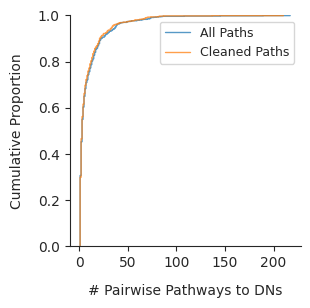

In [8]:
all_pathways   = sided_paths.groupby(group_key)["size"].mean().reset_index()
clean_pathways = clean_paths.groupby(group_key)["size"].mean().reset_index()

# Take a look at the distribution
all_path_counts   = all_pathways[["source", "target"]].value_counts().reset_index()
clean_path_counts = clean_pathways[["source", "target"]].value_counts().reset_index()

# Plot the distribution
fig, ax = plt.subplots(figsize = (4, 3))

# ECDFplot
sns.ecdfplot(all_path_counts,
             x  = "count",
             ax = ax,
             label = "All Paths",
             linewidth = 1,
             alpha = 0.75)

# ECDFplot
sns.ecdfplot(clean_path_counts,
             x  = "count",
             ax = ax,
             label = "Cleaned Paths",
             linewidth = 1,
             alpha = 0.75)

# Despine
sns.despine(ax = ax)
ax.set_box_aspect(1)
ax.legend(fontsize = 9)

# Labels
ax.set_xlabel("# Pairwise Pathways to DNs", labelpad = 10)
ax.set_ylabel("Cumulative Proportion", labelpad = 10)

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Pathways-Cleaning.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Pathways-Cleaning.png",
            dpi = 600,
            bbox_inches = "tight")

## Fetching the Connectivity

Refetching the all-to-all connectivity between every neuron that shows up in the short pathways. Reading the edges off the pathways themselves would only ever show connections that happen to sit on a shortest path, which hides everything else these neurons do with each other.

Everything after this only ever uses a subset of these neurons, so this is the only fetch.

In [9]:
token = os.environ["HEMIBRAIN_TOKEN"]
hemibrain_analysis = connectome_analysis.neuPrintConnect(token = token)

Client version : 1.9.3


In [10]:
# Everything that shows up in the short pathways
x = clean_paths.loc[clean_paths["size"] < 3]
all_ids = np.unique(x["bodyId"])

# Take a look
print(f"# neurons : {len(all_ids)}")
redo = True

# neurons : 276


In [11]:
if redo:
    # Create Criteria
    all_criteria = NC(bodyId = all_ids)

    # Fetch connections
    # min_weight is applied per ROI before the groupby below, so anything above
    # zero quietly drops single synapse slivers and can hide weak edges entirely
    network_df, _ = hemibrain_analysis.connectivity(all_criteria,
                                                    all_criteria,
                                                    min_weight = 1,
                                                    render     = False)

    # Groupby ROI
    network_df = network_df.groupby(["bodyId_pre", "bodyId_post",
                                     "instance_pre", "instance_post",
                                     "type_pre", "type_post"])["weight"].sum().reset_index()

    # Save it
    network_df.to_parquet(f"{path_dir}/LC17_network.parquet",
                          index = False,
                          engine = "pyarrow")

else:
    network_df = pd.read_parquet(f"{path_dir}/LC17_network.parquet",
                                 engine = "pyarrow")

# Take a look
print(f"{len(network_df)} edges | "
      f"{len(set(network_df.bodyId_pre) | set(network_df.bodyId_post))} neurons")
network_df.head()

Client("https://neuprint.janelia.org", "hemibrain:v1.2.1")


  0%|          | 0/2 [00:00<?, ?it/s]

8069 edges | 276 neurons


,bodyId_pre,bodyId_post,instance_pre,instance_post,type_pre,type_post,weight
0,416876055,481657750,SLP278_R,AVLP030_R,SLP278,AVLP030,9
1,416876055,517086196,SLP278_R,AVLP442_R,SLP278,AVLP442,10
2,416876055,673639143,SLP278_R,AVLP215_R,SLP278,AVLP215,12
3,416876055,797442049,SLP278_R,AVLP280_R,SLP278,AVLP280,77
4,416876055,823058891,SLP278_R,CL109_R,SLP278,CL109,2


## Partner - Partner Connectivity

The connections between the partners get removed everywhere after this (no back hopping to the partners), so checking them here first. The partners are also strongly connected to each other, not just feeding forward.

In [12]:
# Connections between the partners
partner_df = network_df.loc[network_df["bodyId_pre"].isin(kept["bodyId"]) &
                            network_df["bodyId_post"].isin(kept["bodyId"])]

# Matrix
partner_types  = sorted(kept["type"].unique())
partner_matrix = pd.crosstab(partner_df.type_pre, partner_df.type_post,
                             values = partner_df.weight,
                             aggfunc = "sum")
partner_matrix = partner_matrix.reindex(index = partner_types, columns = partner_types).fillna(0).astype(int)

# How much of the partners' output stays within the partners
partner_out = network_df.loc[network_df["bodyId_pre"].isin(kept["bodyId"]), "weight"].sum()

# Display
print(f"Partner types : {len(partner_types)} | Edges : {len(partner_df)} | Synapses : {partner_df['weight'].sum()}")
print(f"Partner output onto other partners : {partner_df['weight'].sum() / partner_out * 100:.1f}%")

# Take a look
partner_matrix

Partner types : 15 | Edges : 226 | Synapses : 4319
Partner output onto other partners : 23.3%


type_post,AVLP153,AVLP479,AVLP537,AVLP538,PVLP011,PVLP018,PVLP036,PVLP061,PVLP071,PVLP072,PVLP075,PVLP106,PVLP120,PVLP135,PVLP151
type_pre,,,,,,,,,,,,,,,
AVLP153,0,3,0,25,0,0,40,0,3,2,0,0,53,0,0
AVLP479,2,9,2,261,16,0,6,58,0,38,0,5,0,0,0
AVLP537,8,0,0,32,48,6,26,12,34,13,0,165,0,150,0
AVLP538,19,51,35,0,29,25,26,68,19,58,0,28,28,36,7
PVLP011,2,16,3,7,0,3,73,20,6,6,3,31,4,15,44
PVLP018,0,2,0,8,0,0,0,467,0,14,0,30,27,5,0
PVLP036,51,177,21,159,165,0,0,39,0,9,0,105,0,52,17
PVLP061,16,118,2,13,40,151,4,0,10,37,2,39,0,7,0
PVLP071,0,0,0,22,0,0,0,0,8,0,0,0,0,0,6


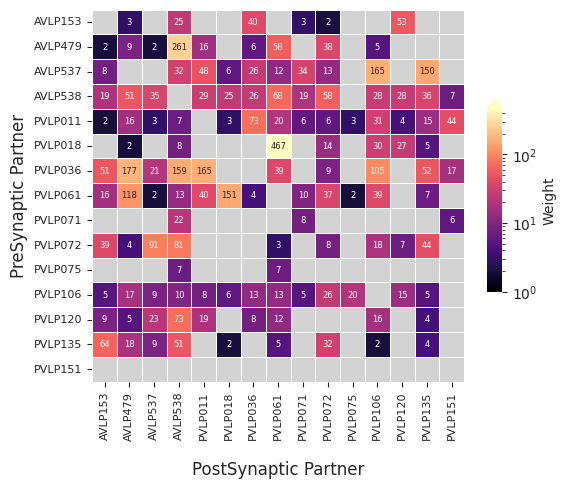

In [13]:
fig, ax = plt.subplots(figsize = (6, 5))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(partner_matrix,
            norm   = LogNorm(1, partner_matrix.values.max()),
            # norm   = PowerNorm(gamma = 0.3, vmin = 0, vmax = partner_matrix.values.max()),
            cmap   = "magma",
            mask   = partner_matrix == 0,
            square = True,
            linewidths = 0.5,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 0,
                         "size"     : 6},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.5,
                         "aspect" : 13,
                         "extend" : "max"},
            xticklabels = True,
            yticklabels = True)

# Labels
ax.set_ylabel("PreSynaptic Partner", fontsize = 12);
ax.set_xlabel("PostSynaptic Partner", labelpad = 15, fontsize = 12);

# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Partner-Inter-Connectivity.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Partner-Inter-Connectivity.png",
            dpi = 600,
            bbox_inches = "tight")

## Removing the LPLC1 / LPLC2 Pathways

Most of the pathways through LPLC1 / LPLC2 go through PVLP011, which synapses onto nearly every LPLC1 and LPLC2 neuron. None of the other top partners come close.

In [14]:
# Direct LC17 partners sit in the first layer
layer_zero = np.unique(kept["type"])
lplc       = ["LPLC1", "LPLC2"]

# Connections from the LC17 partners onto LPLC1 / LPLC2
to_lplc = network_df.loc[network_df["type_post"].isin(lplc) &
                         network_df["type_pre"].isin(layer_zero)]
to_lplc = to_lplc.groupby(["type_pre", "type_post"]).agg(weight    = ("weight", "sum"),
                                                        n_neurons = ("bodyId_post", "nunique")).reset_index()

# Pathways through LPLC1 / LPLC2, and how many of those run through PVLP011
has_lplc    = clean_paths.groupby(group_key)["type"].transform(lambda x : x.isin(lplc).any())
has_pvlp011 = clean_paths.groupby(group_key)["type"].transform(lambda x : (x == "PVLP011").any())

print(f"Pathways through LPLC1 / LPLC2 : {clean_paths[has_lplc].groupby(group_key).ngroups}")
print(f"  of which through PVLP011     : {clean_paths[has_lplc & has_pvlp011].groupby(group_key).ngroups}")

# Take a look
to_lplc.sort_values("weight", ascending = False)

Pathways through LPLC1 / LPLC2 : 587
  of which through PVLP011     : 533


,type_pre,type_post,weight,n_neurons
1,PVLP011,LPLC2,2517,37
0,PVLP011,LPLC1,2302,57
2,PVLP106,LPLC1,95,21
3,PVLP151,LPLC2,4,2


In [15]:
# Drop the pathways through LPLC1 / LPLC2
no_lplc_paths = clean_paths[~has_lplc]

# Size Difference
dropped = clean_paths.groupby(group_key).ngroups - no_lplc_paths.groupby(group_key).ngroups

# Display
print(f"Dropped Pathways : {dropped}")
print(f"Remaining Pathways : {no_lplc_paths.groupby(group_key).ngroups}")

Dropped Pathways : 587
Remaining Pathways : 7275


## Selecting the DNs

Ranking the DNs by how much of the partners' output reaches them, only within the network we already have (after removing LPLC1 / LPLC2).

Can't just add up the pathways, a lot of them share the same neurons so the same synapses get counted over and over. Instead the partners' output is passed through the network, one hop at a time:

1) Every partner starts with its output synapses
2) Every neuron splits what it gets between its targets, based on how many synapses it makes onto each
3) Whatever lands on a DN stays there, since the connections out of the DNs were removed

It only ever gets split and never copied, so nothing is counted twice. Going up to 3 hops, same as the path search.

The score is the % of the partners' output that ends up at each DN.

In [16]:
# The network after removing LPLC1 / LPLC2
dn_ids = np.unique(no_lplc_paths.loc[no_lplc_paths["size"] < max_hops, "bodyId"])
dn_net = network_df.loc[network_df["bodyId_pre"].isin(dn_ids) &
                        network_df["bodyId_post"].isin(dn_ids)]

# The partners
partner_ids = kept["bodyId"]

# Same rules as the network diagram
# Removing self connections
dn_net = dn_net.loc[dn_net["bodyId_pre"] != dn_net["bodyId_post"]]
# Nothing comes out of the DNs
dn_net = dn_net.loc[~(dn_net["type_pre"].str.contains("DN", na = False))]
# No back hopping to the partners
dn_net = dn_net.loc[~(dn_net["bodyId_post"].isin(partner_ids))]

# Display
print(f"Neurons : {len(dn_ids)} | Edges : {len(dn_net)}")

Neurons : 182 | Edges : 3308


Converting the connectivity matrix into the fraction of each neuron's output going to each target.

In [17]:
# Matrix
flow_matrix = pd.crosstab(dn_net.bodyId_pre, dn_net.bodyId_post,
                          values = dn_net.weight,
                          aggfunc = "sum").fillna(0)

# Get all the items
ids = list(set(dn_net["bodyId_pre"]) | set(dn_net["bodyId_post"]))
flow_matrix = flow_matrix.reindex(index = ids, columns = ids).fillna(0)

# Total output of every neuron
out_total = flow_matrix.sum(axis = 1)

# Convert to fractions - each row adds up to 1
# DN rows are all zero, dividing by 1 just leaves them that way
flow_matrix = flow_matrix.div(out_total.replace(0, 1), axis = 0)

# Which of these are DNs
dn_types = dict(zip(dn_net["bodyId_post"], dn_net["type_post"]))
dn_types = {k : v for k, v in dn_types.items() if "DN" in v}

Passing it through for 3 hops, and keeping track of what lands on the DNs at every hop.

In [18]:
# Starting point - the partners with their output synapses, zero everywhere else
flow  = out_total.where(out_total.index.isin(partner_ids), 0)
start = flow.sum()

arrived = []
# Loop over each hop
for hop in range(1, max_hops + 1):

    # Pass it on
    flow = flow.dot(flow_matrix)

    # What reached the DNs this hop
    at_dn = flow.loc[flow.index.isin(dn_types.keys())].reset_index()
    at_dn.columns = ["bodyId", "flow"]
    at_dn["hop"]  = hop

    # Append
    arrived.append(at_dn)

# Convert to DataFrame
arrived = pd.concat(arrived, ignore_index = True)
arrived["type"] = arrived["bodyId"].map(dn_types)

# As % of what the partners started with
arrived["flow"] = arrived["flow"] / start * 100

# Display
print(f"Partner output : {start:.0f} synapses")
print(f"Reached DNs : {arrived['flow'].sum():.1f}%")
print(f"Still in interneurons after {max_hops} hops : {flow.loc[~(flow.index.isin(dn_types.keys()))].sum() / start * 100:.1f}%")

Partner output : 9285 synapses
Reached DNs : 31.8%
Still in interneurons after 3 hops : 68.2%


In [19]:
# Per DN type, hops as columns
dn_rank = pd.crosstab(arrived.type, arrived.hop,
                      values = arrived.flow,
                      aggfunc = "sum").fillna(0)

# Score
dn_rank["score"]     = dn_rank.sum(axis = 1)
dn_rank["n_neurons"] = arrived.groupby("type")["bodyId"].nunique()

# Rank
dn_rank["rank"] = dn_rank["score"].rank(ascending = False, method = "min").astype(int)
dn_rank = dn_rank.sort_values("score", ascending = False)

# Take a look
dn_rank.round(2)

hop,1,2,3,score,n_neurons,rank
type,,,,,,
DNp06,0.46,4.21,4.67,9.35,1,1
DNp23,0.43,1.37,1.01,2.81,2,2
DNp09,0.22,1.38,1.13,2.72,2,3
DNp11,0.04,0.93,1.00,1.97,1,4
DNb01,0.00,0.58,1.24,1.82,2,5
DNp05,0.10,0.68,0.71,1.49,1,6
DNa04,0.02,0.80,0.55,1.37,1,7
DNp04,0.10,0.65,0.40,1.14,1,8
DNa03,0.00,0.34,0.78,1.12,1,9


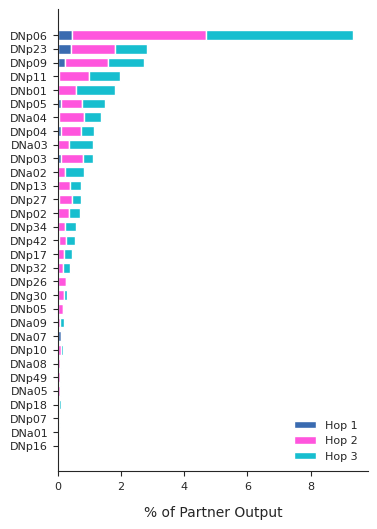

In [20]:
fig, ax = plt.subplots(figsize = (4, 6))

# Colors
hop_colors = ["#3A6BB0", "#ff55dd", "#17becf"]

# Stacking the hops
left = np.zeros(len(dn_rank))
for hop in range(1, max_hops + 1):
    ax.barh(range(len(dn_rank)),
            dn_rank[hop],
            left   = left,
            color  = hop_colors[hop - 1],
            height = 0.7,
            label  = f"Hop {hop}")
    left = left + dn_rank[hop]

ax.set_yticks(range(len(dn_rank)))
ax.set_yticklabels(dn_rank.index)
ax.invert_yaxis()

# Despine
sns.despine(ax = ax)
ax.tick_params(axis = "both", labelsize = 8)
ax.legend(fontsize = 8, frameon = False, loc = "lower right")

# Labels
ax.set_xlabel("% of Partner Output", labelpad = 10)

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_DN-Ranking.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_DN-Ranking.png",
            dpi = 600,
            bbox_inches = "tight")

## Filtering the DNs

Two versions of the network, one for each list of DNs:
1) **Auto** - the top 10 DNs from the flow ranking above
2) **Gio's** - picked by hand

Leave a list empty to keep every DN.

In [21]:
# Top 10 DNs from the flow ranking
auto_filter = dn_rank.loc[dn_rank["rank"] <= 10].index.tolist()

# Gio's DNs
gio_filter = ["DNa01", "DNa02", "DNa03", "DNa04", "DNa10",
              "DNb01", #"DNb02",
              "DNp07", "DNp09"]
              # "DNp03", "DNp04", "DNp06", "DNp07", "DNp09", "DNp10",
              # "DNp11", "DNp18", "DNp23", "DNp31", "DNp42"]

# Prat's DNs
prat_filter = ["DNa01", "DNa02", "DNa03", "DNa04", "DNa10",
              "DNb01",
              "DNp06", "DNp07", "DNp09"]

# Take a look
print(f"Auto   : {auto_filter}")
print(f"Gio's  : {gio_filter}")
print(f"Prat's : {prat_filter}")

Auto   : ['DNp06', 'DNp23', 'DNp09', 'DNp11', 'DNb01', 'DNp05', 'DNa04', 'DNp04', 'DNa03', 'DNp03']
Gio's  : ['DNa01', 'DNa02', 'DNa03', 'DNa04', 'DNa10', 'DNb01', 'DNp07', 'DNp09']
Prat's : ['DNa01', 'DNa02', 'DNa03', 'DNa04', 'DNa10', 'DNb01', 'DNp06', 'DNp07', 'DNp09']


## Network

The neurons are organized into three categories:
1) Post-LC17
2) Intermediate
3) Descending Neurons

The Y axis follows the clustering of the connectivity, so nodes with similar partners land at the same vertical position. In the **Intermediate** layer, nodes are arranged along the X axis based on a spring-force layout.

In [22]:
# Spring layout parameters
spring_k = 1.8
spring_iterations = 400
seed = 39335

# Coordinates
x_left = 0
x_dn   = 10
x_mid_range = (1, 9)

# Colors
colors = {"left" : "#3A6BB0",
          "mid"  : "#ff55dd",
          "DN"   : "#17becf"}

# Mapping - the order matters, first match wins
categories = {
    "AVLP"      : "#ff7f0e",
    "OA | WED"  : "#808080",
    "LAL"       : "#2ca02c",
    "LT | LLPC" : "#d62728",
    "CL"        : "#bcbd22",
    "PLP"       : "#8c564b",
    "PVLP"      : "#ff55dd"}

# Edge width scale
scale = 2

Keeping only the pathways that reach the DNs in the list.

In [23]:
def filter_paths(paths, dn_list):
    """
    Keep the pathways that end on any of the DNs in the list.

    Parameters
    ----------
    paths : DataFrame
        Pathways, one row per node.

    dn_list : list
        DN types to keep. Empty keeps every pathway.

    Returns
    -------
    kept_paths : DataFrame
        The pathways that reach the DNs.

    """
    if not dn_list:
        return paths

    # The DN each pathway ends on - not any DN along the way
    end_type   = paths["target"].map(targets.set_index("bodyId")["type"])
    kept_paths = paths[end_type.isin(dn_list)]

    # Size Difference
    dropped = paths.groupby(group_key).ngroups - kept_paths.groupby(group_key).ngroups

    # Display
    print(f"Dropped Pathways : {dropped}")
    print(f"Remaining Pathways : {kept_paths.groupby(group_key).ngroups}")

    return kept_paths

Type level connectivity between everything in the pathways, already in the all-to-all fetch so just subsetting it.

In [24]:
def get_type_network(paths):
    """
    Type level connectivity between every neuron in the pathways.

    Parameters
    ----------
    paths : DataFrame
        Pathways, one row per node.

    Returns
    -------
    type_df : DataFrame
        Edges between types, with the summed weight.

    """
    # Neurons to plot
    plot_ids = np.unique(paths.loc[paths["size"] < max_hops, "bodyId"])
    plot_df  = network_df.loc[network_df["bodyId_pre"].isin(plot_ids) &
                              network_df["bodyId_post"].isin(plot_ids)]

    # Group by types
    # Type and Instance gives same thing here
    type_df = plot_df.groupby(["type_pre", "type_post"])["weight"].sum().reset_index()

    # Removing self connections
    type_df = type_df.loc[type_df["type_pre"] != type_df["type_post"]]
    # No back hopping to subset
    type_df = type_df.loc[~(type_df["type_post"].isin(layer_zero))]
    # We also want to remove the paths between DNs
    type_df = type_df.loc[~(type_df["type_pre"].str.contains("DN"))]
    # Removing the 5-HTP
    type_df = type_df.loc[~(type_df["type_pre"].str.contains("5-HTP")) &
                          ~(type_df["type_post"].str.contains("5-HTP"))]

    # Display
    print(f"Neurons : {len(plot_ids)} | Edges : {len(plot_df)} | Type Edges : {len(type_df)}")

    return type_df

Positions of every node. X is the layer, with the spring layout spreading out the intermediate ones, and Y is the clustering order.

In [25]:
def get_layout(type_df):
    """
    Graph and node positions for the network diagram.

    Parameters
    ----------
    type_df : DataFrame
        Edges between types, with the summed weight.

    Returns
    -------
    G_u : DiGraph
        The network.

    pos : dict
        (x, y) of every node.

    """
    # Matrix
    type_matrix = pd.crosstab(type_df.type_pre, type_df.type_post,
                              values = type_df.weight,
                              aggfunc = "sum").fillna(0).astype(int)

    # Get all the items
    neus = list(set(type_df["type_pre"]) | set(type_df["type_post"]))
    type_matrix = type_matrix.reindex(index = neus, columns = neus).fillna(0)

    # Cluster based on similarity
    cl = pd.concat((type_matrix, type_matrix.T), axis = 1)
    neu_linkage = linkage(cl, method = "ward", metric = "euclidean")
    neu_order   = leaves_list(neu_linkage)

    # Split into the three layers
    all_nodes    = set(neus)
    dn_nodes     = sorted(n for n in all_nodes if "DN" in n)
    left_nodes   = sorted(n for n in all_nodes if n in layer_zero)
    middle_nodes = sorted(n for n in all_nodes if n not in layer_zero and "DN" not in n)

    # Take a look
    print(f"Post-LC17 : {len(left_nodes)} | Intermediate : {len(middle_nodes)} | DN : {len(dn_nodes)}")

    G_u = nx.from_pandas_edgelist(type_df,
                                  "type_pre",
                                  "type_post",
                                  edge_attr = "weight",
                                  create_using = nx.DiGraph)

    rng = np.random.default_rng(seed)

    # Initial position
    init_pos = {}
    for n in left_nodes:
        init_pos[n] = np.array([x_left, rng.uniform(-3, 3)])
    for n in dn_nodes:
        init_pos[n] = np.array([x_dn, rng.uniform(-3, 3)])
    for n in middle_nodes:
        init_pos[n] = np.array([rng.uniform(-2, 2), rng.uniform(-3, 3)])

    # Fixed
    fixed = set(left_nodes) | set(dn_nodes)

    # Spring
    sp = nx.spring_layout(G_u, pos = init_pos,
                          fixed = fixed,
                          weight = "weight",
                          k = spring_k,
                          iterations = spring_iterations,
                          seed = seed)

    # Rescale the intermediate x
    mid_xs = np.array([sp[n][0] for n in middle_nodes])
    lo, hi = x_mid_range
    scaled = lo + (mid_xs - mid_xs.min()) / (np.ptp(mid_xs) + 1e-12) * (hi - lo)

    # X coordinates
    x_coord = {n : x_left for n in left_nodes}
    x_coord.update({n : x_dn for n in dn_nodes})
    x_coord.update({n : float(scaled[i]) for i, n in enumerate(middle_nodes)})

    # Y coordinates - clustering order, normalised to [0, 100]
    ordered_names = [neus[i] for i in neu_order]
    y_coord = {n : i / max(len(ordered_names) - 1, 1) * 100 for i, n in enumerate(ordered_names)}

    # Merging Final Positions
    pos = {n : (x_coord[n], y_coord[n]) for n in all_nodes}

    return G_u, pos

Drawing the network.

In [26]:
def get_color(node):
    """
    Color of a node, based on its layer and name.

    Parameters
    ----------
    node : string
        Neuron type.

    Returns
    -------
    color : string
        Hex color.

    """
    if "DN" in node:
        return colors["DN"]
    if node in layer_zero:
        return colors["left"]

    # First category whose name shows up in the node
    for names, color in categories.items():
        if any(name in node for name in names.split(" | ")):
            return color

    return colors["mid"]

#------------------------------------------------------------------------------
def plot_network(G_u, pos, filename):
    """
    Draw the network diagram and save it.

    Parameters
    ----------
    G_u : DiGraph
        The network.

    pos : dict
        (x, y) of every node.

    filename : string
        Name of the saved figure, without the extension.

    Returns
    -------
    None.

    """
    fig, ax = plt.subplots(figsize = (12, 12))
    ax.axis("off")

    # Defining edge widths
    edge_widths = np.array([w["weight"] for _, _, w in G_u.edges(data = True)])
    edge_widths = np.sqrt(edge_widths) / scale

    # Node and edge colors
    node_colors = [get_color(node) for node in G_u.nodes()]
    edge_colors = [get_color(pre) + "a1" for pre, _ in G_u.edges()]

    nx.draw_networkx(G_u,
            pos = pos,
            ax  = ax,
            node_size   = 75,
            width       = edge_widths,
            # connectionstyle = "arc3,rad=0.1",
            font_size   = 6,
            linewidths  = 0.25,
            edgecolors  = "black",
            with_labels = True,
            edge_color  = edge_colors,
            node_color  = node_colors)

    # Edges
    sample = np.array([5, 25, 50, 100, 200])
    sizes  = np.sqrt(sample) / scale

    legend_elements = [
        Line2D([0], [0], color = "black", linewidth = s, label = v)
        for v, s in zip(sample, sizes)]

    # Circles
    circle_handles = [
        Line2D([0], [0], color = c,
               marker = "o",
               linestyle = "none",
               markersize = 10,
               label = k)
        for k, c in categories.items()]

    # Weight Legend
    leg1 = ax.legend(handles = legend_elements,
                     title = "Weight",
                     loc = "upper left",
                     bbox_to_anchor = (1.01, 0.9),
                     frameon = False,
                     markerscale = 0.5,
                     fontsize = 8,
                     title_fontsize = 10)
    ax.add_artist(leg1)

    # Circle Legend
    ax.legend(handles = circle_handles,
              title   = "Neuron Groups",
              loc     = "upper left",
              bbox_to_anchor = (1, 0.75),
              frameon = False,
              markerscale = 0.5,
              fontsize = 8,
              title_fontsize = 10)

    # Save it
    plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_{filename}.pdf",
                dpi = 600,
                bbox_inches = "tight")
    plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_{filename}.png",
                dpi = 600,
                bbox_inches = "tight")

### Auto Filter

Dropped Pathways : 4192
Remaining Pathways : 3083
Neurons : 131 | Edges : 2871 | Type Edges : 1805
Post-LC17 : 15 | Intermediate : 77 | DN : 10


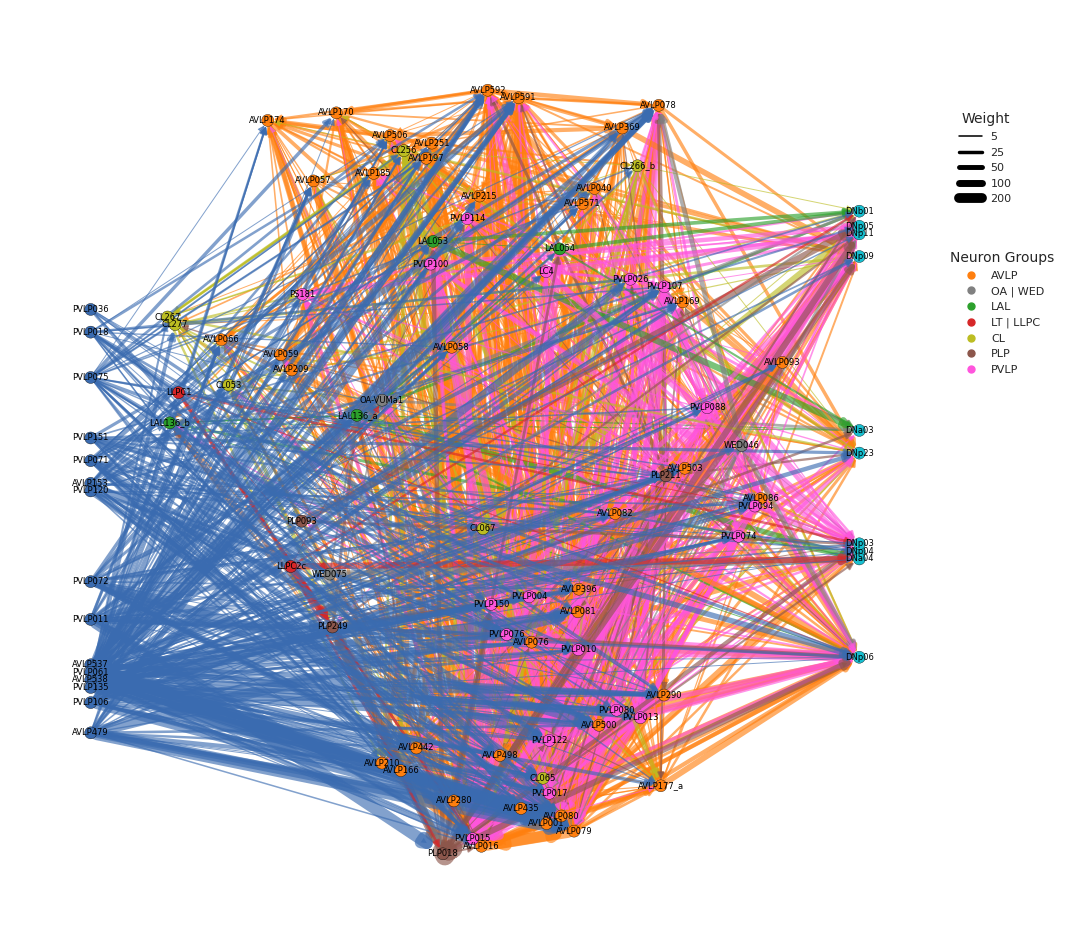

In [27]:
auto_paths = filter_paths(no_lplc_paths, auto_filter)
auto_df    = get_type_network(auto_paths)

G_auto, pos_auto = get_layout(auto_df)
plot_network(G_auto, pos_auto, "Pathways-AutoFilter")

### Gio's Filter

Dropped Pathways : 5478
Remaining Pathways : 1797
Neurons : 71 | Edges : 779 | Type Edges : 344
Post-LC17 : 14 | Intermediate : 29 | DN : 7


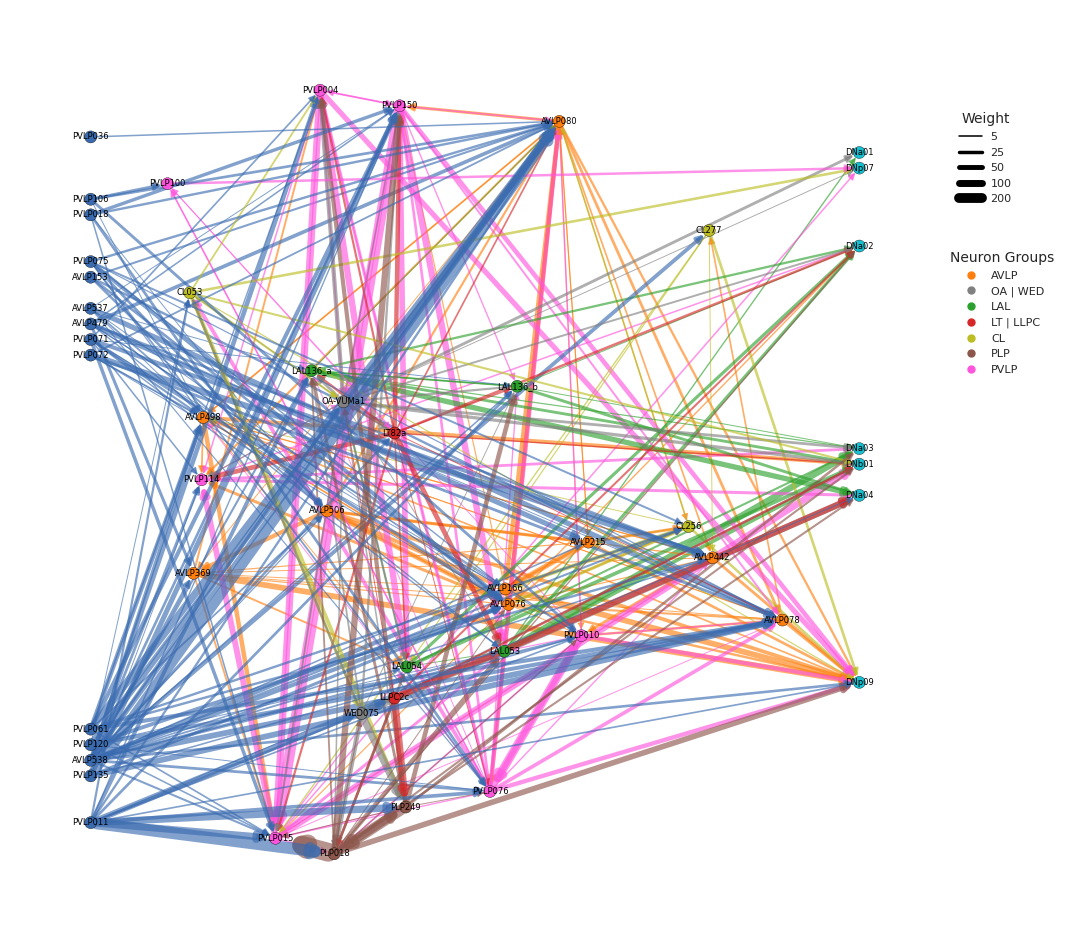

In [28]:
gio_paths = filter_paths(no_lplc_paths, gio_filter)
gio_df    = get_type_network(gio_paths)

G_gio, pos_gio = get_layout(gio_df)
plot_network(G_gio, pos_gio, "Pathways-GioFilter")

### Prat's Filter

Dropped Pathways : 5343
Remaining Pathways : 1932
Neurons : 106 | Edges : 1959 | Type Edges : 1184
Post-LC17 : 14 | Intermediate : 58 | DN : 8


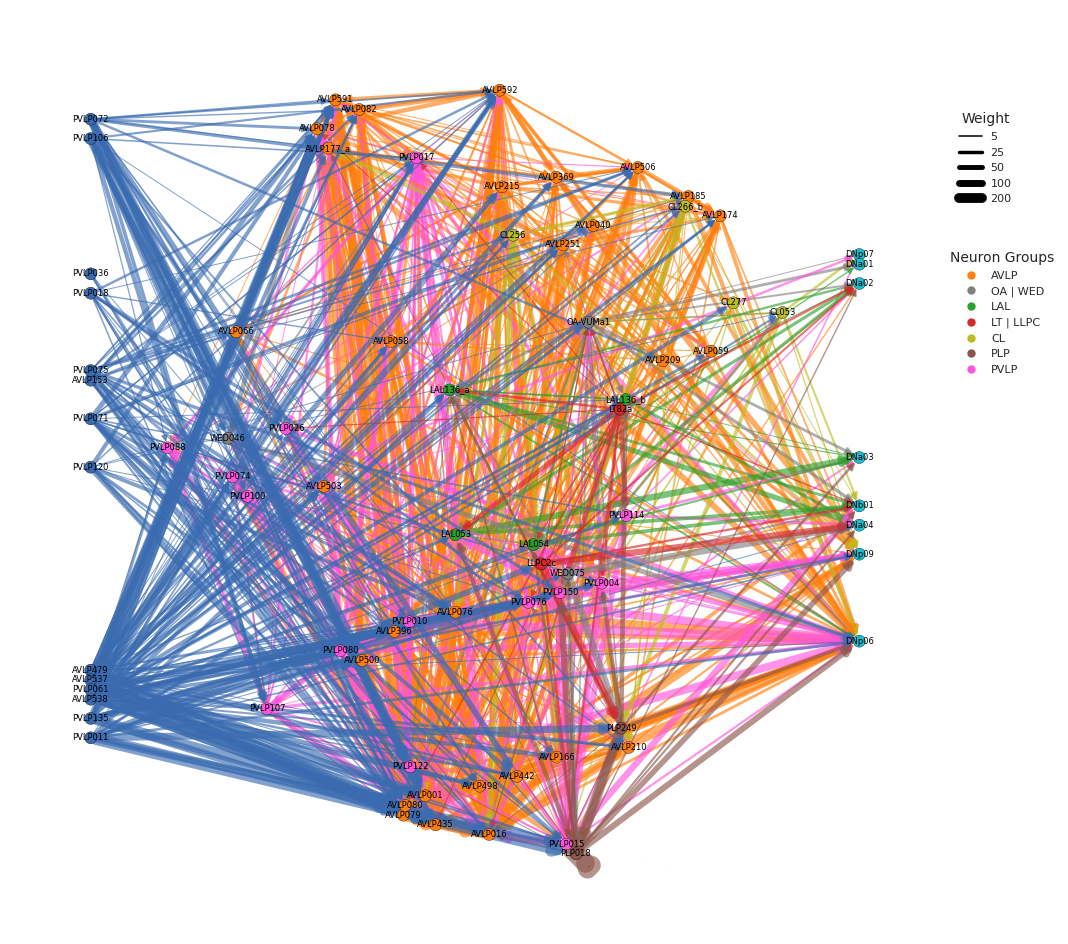

In [29]:
prat_paths = filter_paths(no_lplc_paths, prat_filter)
prat_df    = get_type_network(prat_paths)

G_prat, pos_prat = get_layout(prat_df)
plot_network(G_prat, pos_prat, "Pathways-PratFilter")

## Recurrent Map

Every neuron in Prat's filter network, with all the connections between them straight from the all-to-all fetch. None of the network diagram rules are applied here, so the connections between the partners, back onto the partners, out of the DNs and within a type (the diagonal) are all shown.

Rows are presynaptic, columns are postsynaptic, split into Post-LC17, Intermediate and DNs, each sorted alphabetically. Cells outlined in blue go both ways, with more than 5 synapses in each direction.


Nodes : 80 | Connections : 1481 | Pairs connected both ways : 104 | Types connected to themselves : 3
Not in the network diagram : []


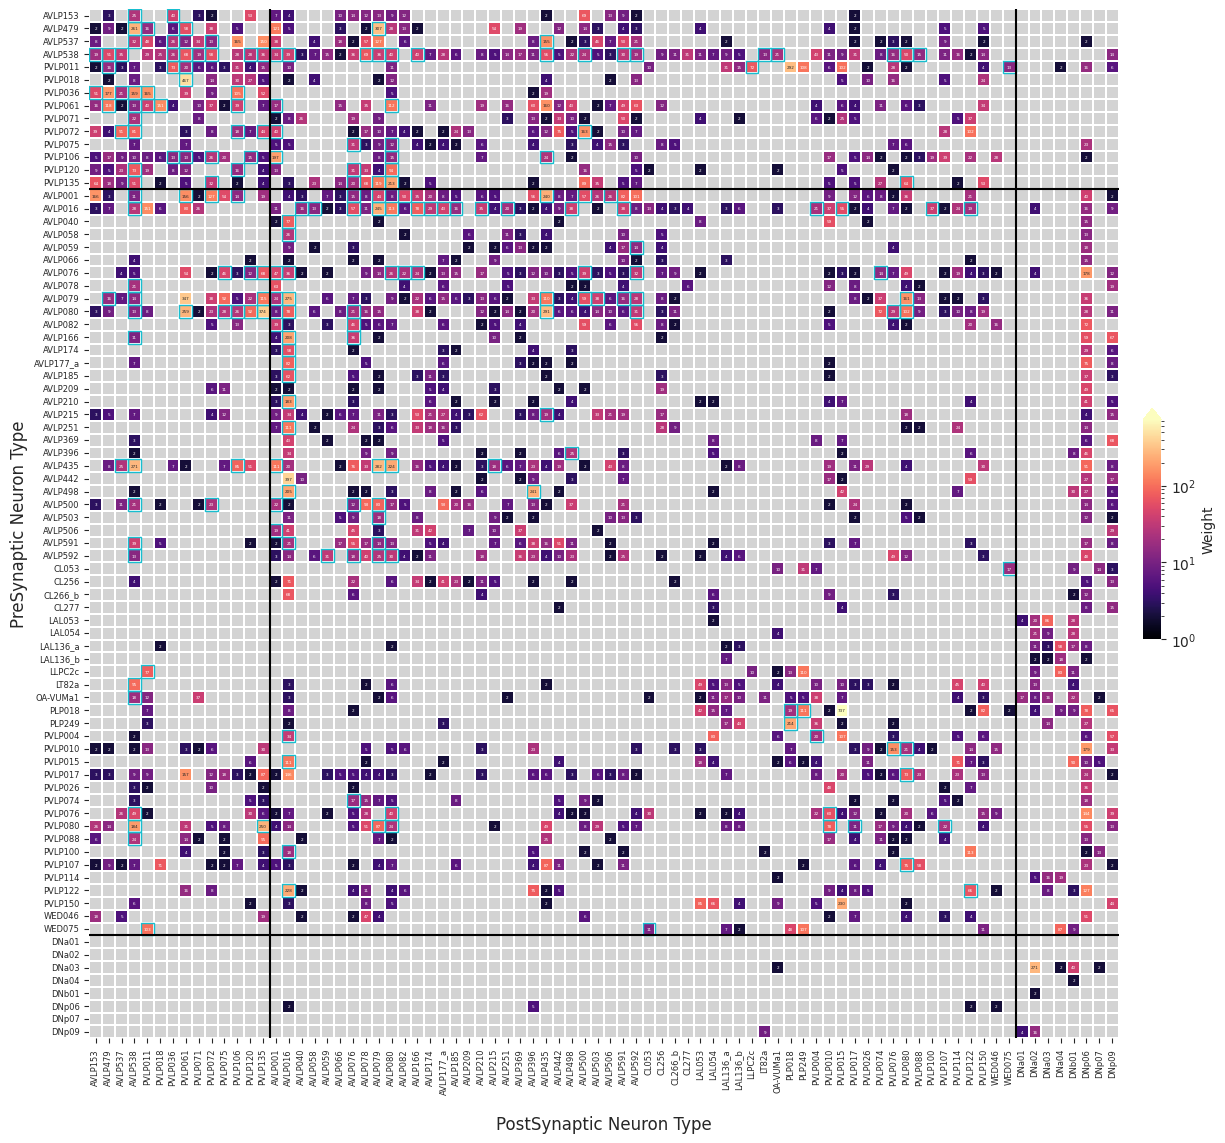

In [30]:
# Every neuron in Prat's filter network
prat_ids = np.unique(prat_paths.loc[prat_paths["size"] < max_hops, "bodyId"])

# All the connections between them - no rules applied
full_df = network_df.loc[network_df["bodyId_pre"].isin(prat_ids)]
full_df = full_df.loc[full_df["bodyId_post"].isin(prat_ids)]

# Matrix
prat_matrix = pd.crosstab(full_df.type_pre, full_df.type_post,
                          values = full_df.weight,
                          aggfunc = "sum")

# Ordering - Post-LC17, Intermediate, DNs, each sorted alphabetically
nodes = set(full_df["type_pre"]) | set(full_df["type_post"])
layer = {n : 0 if n in layer_zero else 2 if "DN" in n else 1 for n in nodes}
order = sorted(nodes, key = lambda n : (layer[n], n))
prat_matrix = prat_matrix.reindex(index = order, columns = order).fillna(0).astype(int)

# Connections that go both ways, more than 5 synapses in each direction
recurrent = (prat_matrix > 10) & (prat_matrix.T > 10)

# Display
n_self = np.diag(recurrent.values).sum()
print(f"Nodes : {len(order)} | Connections : {(prat_matrix > 0).values.sum()} | "
      f"Pairs connected both ways : {(recurrent.values.sum() - n_self) // 2} | "
      f"Types connected to themselves : {n_self}")
print(f"Not in the network diagram : {sorted(nodes - set(pos_prat))}")

fig, ax = plt.subplots(figsize = (16, 15))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(prat_matrix,
            norm   = LogNorm(1, prat_matrix.values.max()),
            cmap   = "magma",
            mask   = prat_matrix == 0,
            square = True,
            linewidths = 0.25,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 0,
                         "size"     : 3},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.2,
                         "pad"    : 0.02,
                         "extend" : "max",
                         "aspect" : 13},
            xticklabels = True,
            yticklabels = True)

# Outline the connections that go both ways
for i, j in zip(*np.where(recurrent.values)):
    ax.add_patch(plt.Rectangle((j, i), 1, 1,
                               fill = False,
                               edgecolor = colors["DN"],
                               linewidth = 1))

# Split the layers
n_left = sum(layer[n] == 0 for n in order)
n_mid  = sum(layer[n] == 1 for n in order)
for edge in [n_left, n_left + n_mid]:
    ax.axhline(edge, color = "black", linewidth = 1.5)
    ax.axvline(edge, color = "black", linewidth = 1.5)

# Labels
ax.set_ylabel("PreSynaptic Neuron Type", fontsize = 12);
ax.set_xlabel("PostSynaptic Neuron Type", labelpad = 15, fontsize = 12);

# Tick params
ax.tick_params(axis = "both", labelsize = 6)

# Save
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Pathways-PratFilter-Recurrence.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Pathways/{dataset}/{dataset}_LC17_Pathways-PratFilter-Recurrence.png",
            dpi = 600,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों**</center>